# Binomial Model for Option Pricing

*Jun Shen, April 7th 2026 @ UK*

## 1. Introduction to the Model
* The **Binomial Model** is an accessible approach to option pricing using basic arithmetic instead of complex stochastic calculus.
* It models asset prices as a **random walk** where the price can only move up or down in a discrete time step $\delta t$.
* **Key Assumptions**:
    * Zero interest rates (initially, for simplicity).
    * No arbitrage opportunities.
    * The stock price moves from $S$ to either $uS$ (up) or $vS$ (down).

---

## 2. Delta Hedging and No Arbitrage
* **Delta Hedging**: Risk is eliminated by constructing a portfolio consisting of one option and a short position in $\Delta$ amount of the underlying stock.
* **Formula for Delta**: $\Delta = \frac{V^+ - V^-}{(u - v)S}$, which represents the sensitivity of the option to the stock price.
* **No Arbitrage**: Since the hedged portfolio is risk-free, it must earn the risk-free interest rate $r$.
* **The Big Insight**: The value of an option does **not** depend on the real-world probability ($p$) of the stock rising or the stock's growth rate ($\mu$). It only cares about volatility.

---

## 3. Risk Neutrality
* **Risk-Neutral World**: A theoretical world where investors are indifferent to risk and do not require extra return for taking it.
* **Risk-Neutral Probability ($p'$)**:
    * Calculated as $p' = \frac{1 - v + r \delta t}{u - v}$.
    * In this world, the option value is simply the **present value of the expected payoff**.
* **Formula for Option Value ($V$)**:
    $$V = \frac{1}{1 + r \delta t} [p'V^+ + (1 - p')V^-]$$

---

## 4. From Discrete to Continuous Time
* To match the binomial model with the continuous-time Lognormal model (SDE), we choose specific values for $u$ and $v$ based on volatility ($\sigma$):
    * $u = 1 + \sigma\sqrt{\delta t}$
    * $v = 1 - \sigma\sqrt{\delta t}$
* **The Binomial Tree**: By extending the walk over many steps, we create a tree. We value the option by working **backward** from the expiration date to the present.
* **Black-Scholes**: As the time step $\delta t \to 0$, the binomial model converges to the **Black-Scholes partial differential equation**:
    $$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS \frac{\partial V}{\partial S} - rV = 0$$

---

## 5. Summary Table
| Feature | Real World | Risk-Neutral World |
| :--- | :--- | :--- |
| **Growth Rate** | Uses $\mu$ (Drift) | Uses $r$ (Interest Rate) |
| **Probabilities** | Real $p$ and $1-p$ | Risk-neutral $p'$ and $1-p'$ |
| **Pricing Method** | Delta Hedging / No Arbitrage | Simple Expectations |
| **Option Value** | Same | Same |

# Example: One-Period Binomial Option Pricing (Delta Hedging Method)

## 1. Market Data & Assumptions
* **Current Stock Price ($S_0$):** \$100
* **Strike Price ($K$):** \$100
* **Up Move ($u$):** $1.01$ (Stock $S_1^u = \$101$)
* **Down Move ($v$):** $0.99$ (Stock $S_1^d = \$99$)
* **Risk-free Interest Rate ($r$):** $0\%$ (Discount factor = $1$)
* **Time Step ($\delta t$):** 1 day

---

## 2. Binomial Tree Visualization
```text
      Time 0                Time 1
      (Now)                (Expiry)
                           /--- $S_1^u = \$101$ ($V_1^u = \$1$)
      $S_0 = \$100$ <
                           \--- $S_1^d = \$99$ ($V_1^d = \$0$)
```
## 3. Step-by-Step Calculation (No-Arbitrage Approach)

### Step A: Determine Option Payoffs at Expiry
* **If Stock goes Up:** $V_1^u = \max(S_1^u - K, 0) = \max(101 - 100, 0) = \$1$
* **If Stock goes Down:** $V_1^d = \max(S_1^d - K, 0) = \max(99 - 100, 0) = \$0$

### Step B: Calculate the Hedging Ratio (Delta)
To create a risk-free portfolio consisting of **long $\Delta$ shares and short 1 call option**, the value of the portfolio at Time 1 must be identical regardless of the stock price movement:
$$\Delta S_1^u - V_1^u = \Delta S_1^d - V_1^d$$

Substitute the values:
$$\Delta (101) - 1 = \Delta (99) - 0$$
$$101\Delta - 99\Delta = 1$$
$$2\Delta = 1 \implies \Delta = 0.5$$

### Step C: Direct Valuation of the Option ($V_0$)
Since the hedged portfolio is risk-free, its value today must equal the present value of its future payoff. Given $r = 0$, the discount factor is $1$.

**1. Calculate the Future Portfolio Value (at $T=1$):**
Check the "Up" state: $0.5(101) - 1 = \$49.5$
Check the "Down" state: $0.5(99) - 0 = \$49.5$
The portfolio value is constant at **\$49.5**.

**2. Solve for $V_0$ (at $T=0$):**
The value of the portfolio today is the value of the components at $T=0$:
$$\Delta S_0 - V_0 = \text{Future Portfolio Value} \times e^{-r\delta t}$$
$$0.5(100) - V_0 = 49.5$$
$$50 - V_0 = 49.5$$
$$V_0 = 0.5$$

---

## 4. Final Summary
* **Hedging Ratio ($\Delta$):** 0.5 shares
* **Risk-Free Portfolio Value:** \$49.5
* **Call Option Price ($V_0$):** **\$0.5**

# Core Concepts of the Binomial Model

## 1. What is Delta Hedging?
**Delta Hedging** is a strategy used to eliminate the risk of an option position by holding a specific quantity of the underlying stock.
* We construct a portfolio consisting of one option and a short position in a quantity $\Delta$ of the stock.
* By choosing the correct $\Delta$, the portfolio value becomes the same tomorrow regardless of whether the stock rises or falls.
* The formula for this "perfect" ratio is:
  $$\Delta = \frac{\text{Range of option payoffs}}{\text{Range of stock prices}}$$

## 2. What is No Arbitrage?
**No Arbitrage** is the principle that there is no such thing as "free money" in an efficient market.
* If two different portfolios (e.g., a hedged option and a cash deposit) produce the exact same risk-free value tomorrow, they **must** cost the same today.
* If the prices were different, a trader could buy the cheap one and sell the expensive one to lock in a guaranteed profit without taking any risk.
* Market forces (supply and demand) will quickly push the option price back to its "theoretical" fair value.

## 3. Why $\mu$ (Growth Rate) Doesn't Matter
It is a common misconception that a stock's expected growth rate ($\mu$) affects the option price.
* Because we use **Delta Hedging**, we have neutralized the direction of the stock.
* Whether the stock has a $90\%$ or a $10\%$ chance of rising is irrelevant because our hedged portfolio is designed to be worth the same in either scenario.
* In the pricing formula, the actual probability $p$ (which depends on $\mu$) is replaced by the **risk-neutral probability $p'$** (which depends only on $r$).

## 4. Why $\sigma$ (Volatility) Matters
While we don't care about the *direction*, we care deeply about the **range** of the stock price.
* **Volatility ($\sigma$)** determines how far the stock can "jump" up ($u$) or down ($v$).
* A higher $\sigma$ means a wider range of possible future stock prices, which increases the potential payoff of the option.
* Therefore, the option value is highly sensitive to the stock's volatility.

---

## 5. The Counterintuitive Example
Imagine two stocks, **A** and **B**, that currently have the same price and the same volatility.
* **Stock A** is doubling in value every year (High $\mu$).
* **Stock B** is halving in value every year (Negative $\mu$).
* **The Reality**: The call options for both stocks have the **exact same value** today.

**Why?** Because if you are hedging, you don't care that Stock A is "better". You only care that you can replicate the option's payoff using the stock and cash. Since both stocks have the same volatility, the cost of replicating (and thus the price) is identical.

# Other Method: Risk-Neutral Probability/Recombining Lattice

## Mathematical Derivation of $u$, $v$, and $p'$

To ensure the discrete Binomial Model accurately represents the continuous-time asset price behavior, we match its first two moments (**Mean** and **Variance**) to those of the lognormal random walk.

---

## 1. Matching the Mean (First Moment)
In the continuous model, the expected change in asset price over a small time step $\delta t$ is $$\mathbb{E}[dS]=\mathbb{E}[\mu S \delta t + \sigma S \delta X] = \mu S \delta t$$
where $\mathbb{E}[\delta X] = 0$.

In the Binomial Model, the expected change is calculated by the probability-weighted sum of the two possible price changes:
* **Up move change**: $(uS - S)$ with probability $p$
* **Down move change**: $(vS - S)$ with probability $(1-p)$

**The Mean Equation:** $$p(uS - S) + (1-p)(vS - S) = \mu S \delta t$$
Dividing by $S$ and simplifying:
$$p(u - 1) + (1 - p)(v - 1) = \mu \delta t$$
$$pu + (1 - p)v - 1 = \mu \delta t \quad \implies \quad pu + (1 - p)v = 1 + \mu \delta t$$

---

## 2. Matching the Variance (Second Moment)
The variance of the change in the lognormal model is $$\mathbb{Var}[dS]=\mathbb{Var}[\underbrace{\mu S \delta t}_{\text{Constant}}+ \sigma S \delta X] = \sigma^2 S^2 \delta t$$
where $\mathbb{Var}[\delta X] = \delta t$.

Recall that for a random variable $X$, its variance is defined by
$$\mathbb{Var}[X] = E[(X-E[X])^{2}]=\sum_{i} p_{i}(x_{i}-\bar{x})^{2}$$
In the Binomial Model, the variance is the expected value of the squared deviations from the mean:
$$\text{Variance} = p[S(u-1) - \mu S \delta t]^2 + (1-p)[S(v-1) - \mu S \delta t]^2$$

**The Variance Equation:** $$S^2 [p(u - 1 - \mu \delta t)^2 + (1 - p)(v - 1 - \mu \delta t)^2] = \sigma^2 S^2 \delta t$$
As $\delta t \to 0$, the terms involving $(\mu \delta t)^2$ become negligible (higher-order infinitesimals), leading to the simplified approximation used to solve for parameters:
$$p(u-1)^2 + (1-p)(v-1)^2 \approx \sigma^2 \delta t$$

---

## 3. Solving for $u, v,$ and $p$
Since we have three unknowns ($u, v, p$) but only two equations (mean and variance), there are infinite solutions. We choose the most mathematically "elegant" set:

* **Step 1: Set a symmetry condition.** We often assume $u - 1 = -(v - 1)$ for the variance match at leading order, or $uv = 1$ for a recombining tree (the tree thus will not explode as the time step increases).
* **Step 2: Solve for $u$ and $v$.** Using the variance equation:
    $$u = 1 + \sigma\sqrt{\delta t} \quad \text{and} \quad v = 1 - \sigma\sqrt{\delta t}$$
* **Step 3: Solve for $p$.** Substituting $u$ and $v$ back into the Mean Equation:

    $$p(1 + \sigma\sqrt{\delta t}) + (1 - p)(1 - \sigma\sqrt{\delta t}) = 1 + \mu \delta t$$

    $$1 - \sigma\sqrt{\delta t} + 2p\sigma\sqrt{\delta t} = 1 + \mu \delta t$$
    $$p = \frac{1}{2} + \frac{\mu \sqrt{\delta t}}{2\sigma}$$

---

## 4. Deriving the Risk-Neutral Probability ($p'$)
In the **Risk-Neutral World**, we replace the real-world growth rate $\mu$ with the risk-free rate $r$.

Using the same algebraic steps as above but substituting $\mu$ for $r$:
1.  **Risk-Neutral Mean Requirement**: If we assume that the investors are risk-netural, then
$$E[S_{\text{new}}]=p'(uS)+(1-p')(dS)$$
where $p'$ is the risk-neutral probability, $u$ and $v$ are the scaling factors, and $S$ is the original stock price. Dividing both sides of the equation by S: $$\frac{E[S_{\text{new}}]}{S}=p'u+(1-p')d$$ Equivalently, $$\frac{E[S_{\text{new}}]}{S}-1=p'u+(1-p')d-1$$ The left-hand-side is the percentage return of the stock $$\frac{E[S_{\text{new}}]}{S}-1=\frac{E[S_{\text{new}}]-S}{S}$$ Under risk-neutrality assumption, investors would not ask for additional compensation for taking risks, and the only return expected should be the risk-free interest rate (return), $r \delta t$, thus we have
$$1 + r \delta t = p'u + (1 - p')v $$
2.  **Solve for $p'$**:
    $$p' = \frac{(1 + r \delta t) - v}{u - v}$$
    Substituting the values for $u$ and $v$:
    $$p' = \frac{1 + r \delta t - (1 - \sigma\sqrt{\delta t})}{(1 + \sigma\sqrt{\delta t}) - (1 - \sigma\sqrt{\delta t})} = \frac{\sigma\sqrt{\delta t} + r \delta t}{2\sigma\sqrt{\delta t}}$$
    $$p' = \frac{1}{2} + \frac{r \sqrt{\delta t}}{2\sigma}$$


# Derivation of Continuous-Time Limit

This derivation moves from the discrete Binomial Tree to the continuous-time framework by treating the option value as a smooth function $V(S, t)$ and applying Taylor Series expansion.

---

## 1. Defining the Function and Steps
We represent the option price not as a collection of numbers, but as a function of stock price $S$ and time $t$: **$V(S, t)$**.

In a single time step $\delta t$, the option value at the next step ($t + \delta t$) will be one of two values:
* **$V^+$ (Up move):** $V(uS, t + \delta t) = V((1 + \sigma\sqrt{\delta t})S, t + \delta t)$
* **$V^-$ (Down move):** $V(vS, t + \delta t) = V((1 - \sigma\sqrt{\delta t})S, t + \delta t)$

We use the parameter definitions:
* $u = 1 + \sigma\sqrt{\delta t}$
* $v = 1 - \sigma\sqrt{\delta t}$

---

## 2. Taylor Series Expansion
To find the continuous limit, we expand $V^+$ and $V^-$ around $(S, t)$ for a small $\delta t$:

**For $V^+$:**
$$V^+ \approx V(S,t) + \frac{\partial V}{\partial t}\delta t + \frac{\partial V}{\partial S}(\sigma\sqrt{\delta t}S) + \frac{1}{2}\frac{\partial^{2}V}{\partial S^{2}}(\sigma\sqrt{\delta t}S)^{2} + \dots$$

**For $V^-$:**
$$V^- \approx V(S,t) + \frac{\partial V}{\partial t}\delta t - \frac{\partial V}{\partial S}(\sigma\sqrt{\delta t}S) + \frac{1}{2}\frac{\partial^{2}V}{\partial S^{2}}(-\sigma\sqrt{\delta t}S)^{2} + \dots$$

---

## 3. Deriving Delta ($\Delta$) in the Limit
Recall the discrete formula for Delta:
$$\Delta = \frac{V^+ - V^-}{(u - v)S}$$

Substitute the Taylor expansions of $V^+$ and $V^-$ into the numerator:
* $V^+ - V^- \approx 2 \frac{\partial V}{\partial S} \sigma\sqrt{\delta t} S$
* $(u - v)S = (1 + \sigma\sqrt{\delta t} - (1 - \sigma\sqrt{\delta t}))S = 2\sigma\sqrt{\delta t} S$

As $\delta t \to 0$:
$$\Delta = \frac{\partial V}{\partial S}$$
This shows that Delta is the **sensitivity (derivative)** of the option price with respect to the stock price.

---

## 4. Deriving the Continuous Pricing Equation
The discrete pricing equation (assuming $r$ is non-zero) is:
$$V = \frac{1}{1 + r \delta t} [p'V^+ + (1 - p')V^-]$$

When we substitute the Taylor expansions and the risk-neutral probability $p' = \frac{1}{2} + \frac{r\sqrt{\delta t}}{2\sigma}$ into this equation and let $\delta t \to 0$, the terms rearrange into a Partial Differential Equation (PDE):

$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS \frac{\partial V}{\partial S} - rV = 0$$

---

## 5. Summary of the Transition to Brownian Motion
* **Diffusion Term ($\frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}$):** This arises from the variance matching of the binomial walk, representing the "randomness" or Brownian motion component.
* **Drift Term ($rS \frac{\partial V}{\partial S}$):** This replaces the real growth $\mu$ because of risk neutrality.
* **Result:** The binomial model converges exactly to the **Black-Scholes equation**, which is the continuous-time equivalent of the risk-neutral binomial walk.

In [226]:
# Multi-step Binomial Model: European Options (Delta Hedging Method)
# Implementation: Path-based (storing unique paths like 'uud', 'udu' as keys)
# Time Complexity: O(2^T)  |  Space Complexity: O(2^T)


import numpy as np
from itertools import product

def get_stock_prices_at_t(s0, t, u, d):
    """
    Computes stock prices for all paths at time step t.
    Example for t=2:
        Paths generated: ('u','u'), ('u','d'), ('d','u'), ('d','d')
        Calculation: 'ud' -> s0 * u^1 * d^1
    """
    price_map = {}
    all_paths = list(product(*[('u', 'd')] * t))

    for path_tuple in all_paths:
        path_str = ''.join(path_tuple)
        up_count = path_str.count("u")
        down_count = path_str.count("d")
        price = s0 * (u ** up_count) * (d ** down_count)
        price_map[path_str] = price

    return price_map

def get_eu_payoff(s, k, option_type='call'):
    """Calculates Max(S-K, 0) for Call or Max(K-S, 0) for Put."""
    if option_type.lower() == 'call':
        return max(s - k, 0)
    return max(k - s, 0)

def pair_nodes_by_path(data_dict):
    """
    Sorts keys and pairs them to represent branching from the same parent node.

    Example for t=2:
        data_dict: {'dd': 2.5, 'du': 10.0, 'ud': 10.0, 'uu': 40.0}
        Sorted Keys: ['dd', 'du', 'ud', 'uu']
        Pairs: [[2.5, 10.0], [10.0, 40.0]]  <-- [ [V_down, V_up], [V_down, V_up] ]
    """
    sorted_keys = sorted(data_dict.keys())
    values = [data_dict[k] for k in sorted_keys]
    # We use a step of 2 to group siblings (the 'down' move and 'up' move from same parent)
    pairs = [values[i:i+2] for i in range(0, len(values), 2)]
    return pairs, sorted_keys

def calculate_hedge_delta(opt_pairs, stock_pairs):
    """
    Calculates Delta (Δ) for each pair of nodes.
    Example:
        If opt_pair = [0, 10] and stock_pair = [10, 40]
        Delta = (10 - 0) / (40 - 10) = 0.333
    """
    deltas = []
    for i in range(len(opt_pairs)):
        # index 1 is 'u' (Up), index 0 is 'd' (Down) because 'd' < 'u' in alphabet
        v_diff = opt_pairs[i][1] - opt_pairs[i][0]
        s_diff = stock_pairs[i][1] - stock_pairs[i][0]
        deltas.append(v_diff / s_diff)
    return deltas

def backtrack_option_value(s0, t_current, v_t, u, d, k, r, option_type='call'):
    """
    Backtracks option value using the Replication Portfolio (Delta Hedging).

    Logic:
        To replicate an option, you hold Delta(Δ) amount of stock and
        borrow/lend the remaining amount (Bond).
    """
    prices_t = get_stock_prices_at_t(s0, t_current, u, d)
    prices_prev = get_stock_prices_at_t(s0, t_current - 1, u, d)

    opt_pairs, sorted_keys_t = pair_nodes_by_path(v_t)
    stock_pairs_t, _ = pair_nodes_by_path(prices_t)

    # Matching the previous stock price to the correct pair
    sorted_keys_prev = sorted(prices_prev.keys())
    stock_prev_list = [prices_prev[k] for k in sorted_keys_prev]

    deltas = calculate_hedge_delta(opt_pairs, stock_pairs_t)
    v_prev_map = {}

    if t_current - 1 != 0:
        # Example for parent_path:
        # If current paths are 'uud' and 'uuu', the parent is 'uu' (strip the last char)
        parent_paths = [sorted_keys_t[i][:-1] for i in range(0, len(sorted_keys_t), 2)]

        for i in range(len(deltas)):
            v_down, s_down = opt_pairs[i][0], stock_pairs_t[i][0]

            # The cost of the replication portfolio:
            # 1. (v_down - deltas[i] * s_down) is the Cash/Bond component at time t
            # 2. We discount the bond component back 1 period
            # 3. Add the current value of the stock held (delta * S_{t-1})
            bond_part = (v_down - deltas[i] * s_down) * np.exp(-r)
            stock_part = deltas[i] * stock_prev_list[i]

            v_prev_map[parent_paths[i]] = bond_part + stock_part
    else:
        # Root node (t=0) has no string path (empty string)
        v_down, s_down = opt_pairs[0][0], stock_pairs_t[0][0]
        v_root = (v_down - deltas[0] * s_down) * np.exp(-r) + deltas[0] * stock_prev_list[0]
        v_prev_map = v_root

    return v_prev_map

def price_european_option(s0, t_maturity, u, d, k, r, option_type='call'):
    """
    Main entry point.
    Loops from T down to 1 to find the option price at t=0.
    """
    # 1. Calculate Option Payoffs at Maturity (T)
    current_values = {}
    final_prices = get_stock_prices_at_t(s0, t_maturity, u, d)
    for path, s_price in final_prices.items():
        current_values[path] = get_eu_payoff(s_price, k, option_type)

    # 2. Iteratively backtrack: (T -> T-1), (T-1 -> T-2) ... (1 -> 0)
    for t in range(t_maturity, 0, -1):
        current_values = backtrack_option_value(s0, t, current_values, u, d, k, r, option_type)

    return current_values

# --- Practical Test Case ---
# s0=20, K=30, T=3, r=0.0, u=2, d=0.5
# Expected Call Price: ~7.037 (as calculated in previous logic)
# result = price_european_option(20, 3, 2, 0.5, 30, 0.0, 'call')

In [225]:
price_european_option(s0=20, t_maturity=20, u=1.5, d=0.35, k=11, r=0.04)

np.float64(18.523095810186252)

# 💡 Smart Way: Risk Neutral Probability/Recombining Lattice

In a standard path-dependent tree, the number of paths grows exponentially ($2^T$). However, in a **Recombining Lattice**, we assume that an "Up-then-Down" move ($ud$) results in the exact same price as a "Down-then-Up" move ($du$).

By merging these overlapping paths, we transform a massive tree into a manageable grid, drastically increasing calculation speed!



---

### 1. Key Definitions

* **T**: Total number of time steps.
* **j**: The total count of **UP** movements reached at a specific node.
* **p**: The risk-neutral probability of an **UP** move.
* **1-p**: The risk-neutral probability of a **DOWN** move.
* **C(T, j)**: The Binomial Coefficient (Path Count), representing how many unique paths lead to exactly $j$ up moves in $T$ steps.

---

### 2. The Core Logic: How to Calculate Probability?

To find the total probability of reaching a specific price node, we use the following formula:

$$P = C(T, j) \times p^j \times (1-p)^{n-j}$$

**Example (Assume n=2 steps):**

If we want to find the probability of ending with **1 Up and 1 Down** ($j=1$):

1. **Path Count C(2, 1):** There are **2** distinct paths to get here (`ud` and `du`). So $C(2, 1) = 2$.
2. **Up Probability (p^j):** We moved up 1 time, so we have $p^1$.
3. **Down Probability ((1-p)^{n-j}):** We moved down 1 time, so we have $(1-p)^1$.

**Total Probability for that node** = $2 \times p \times (1-p)$.



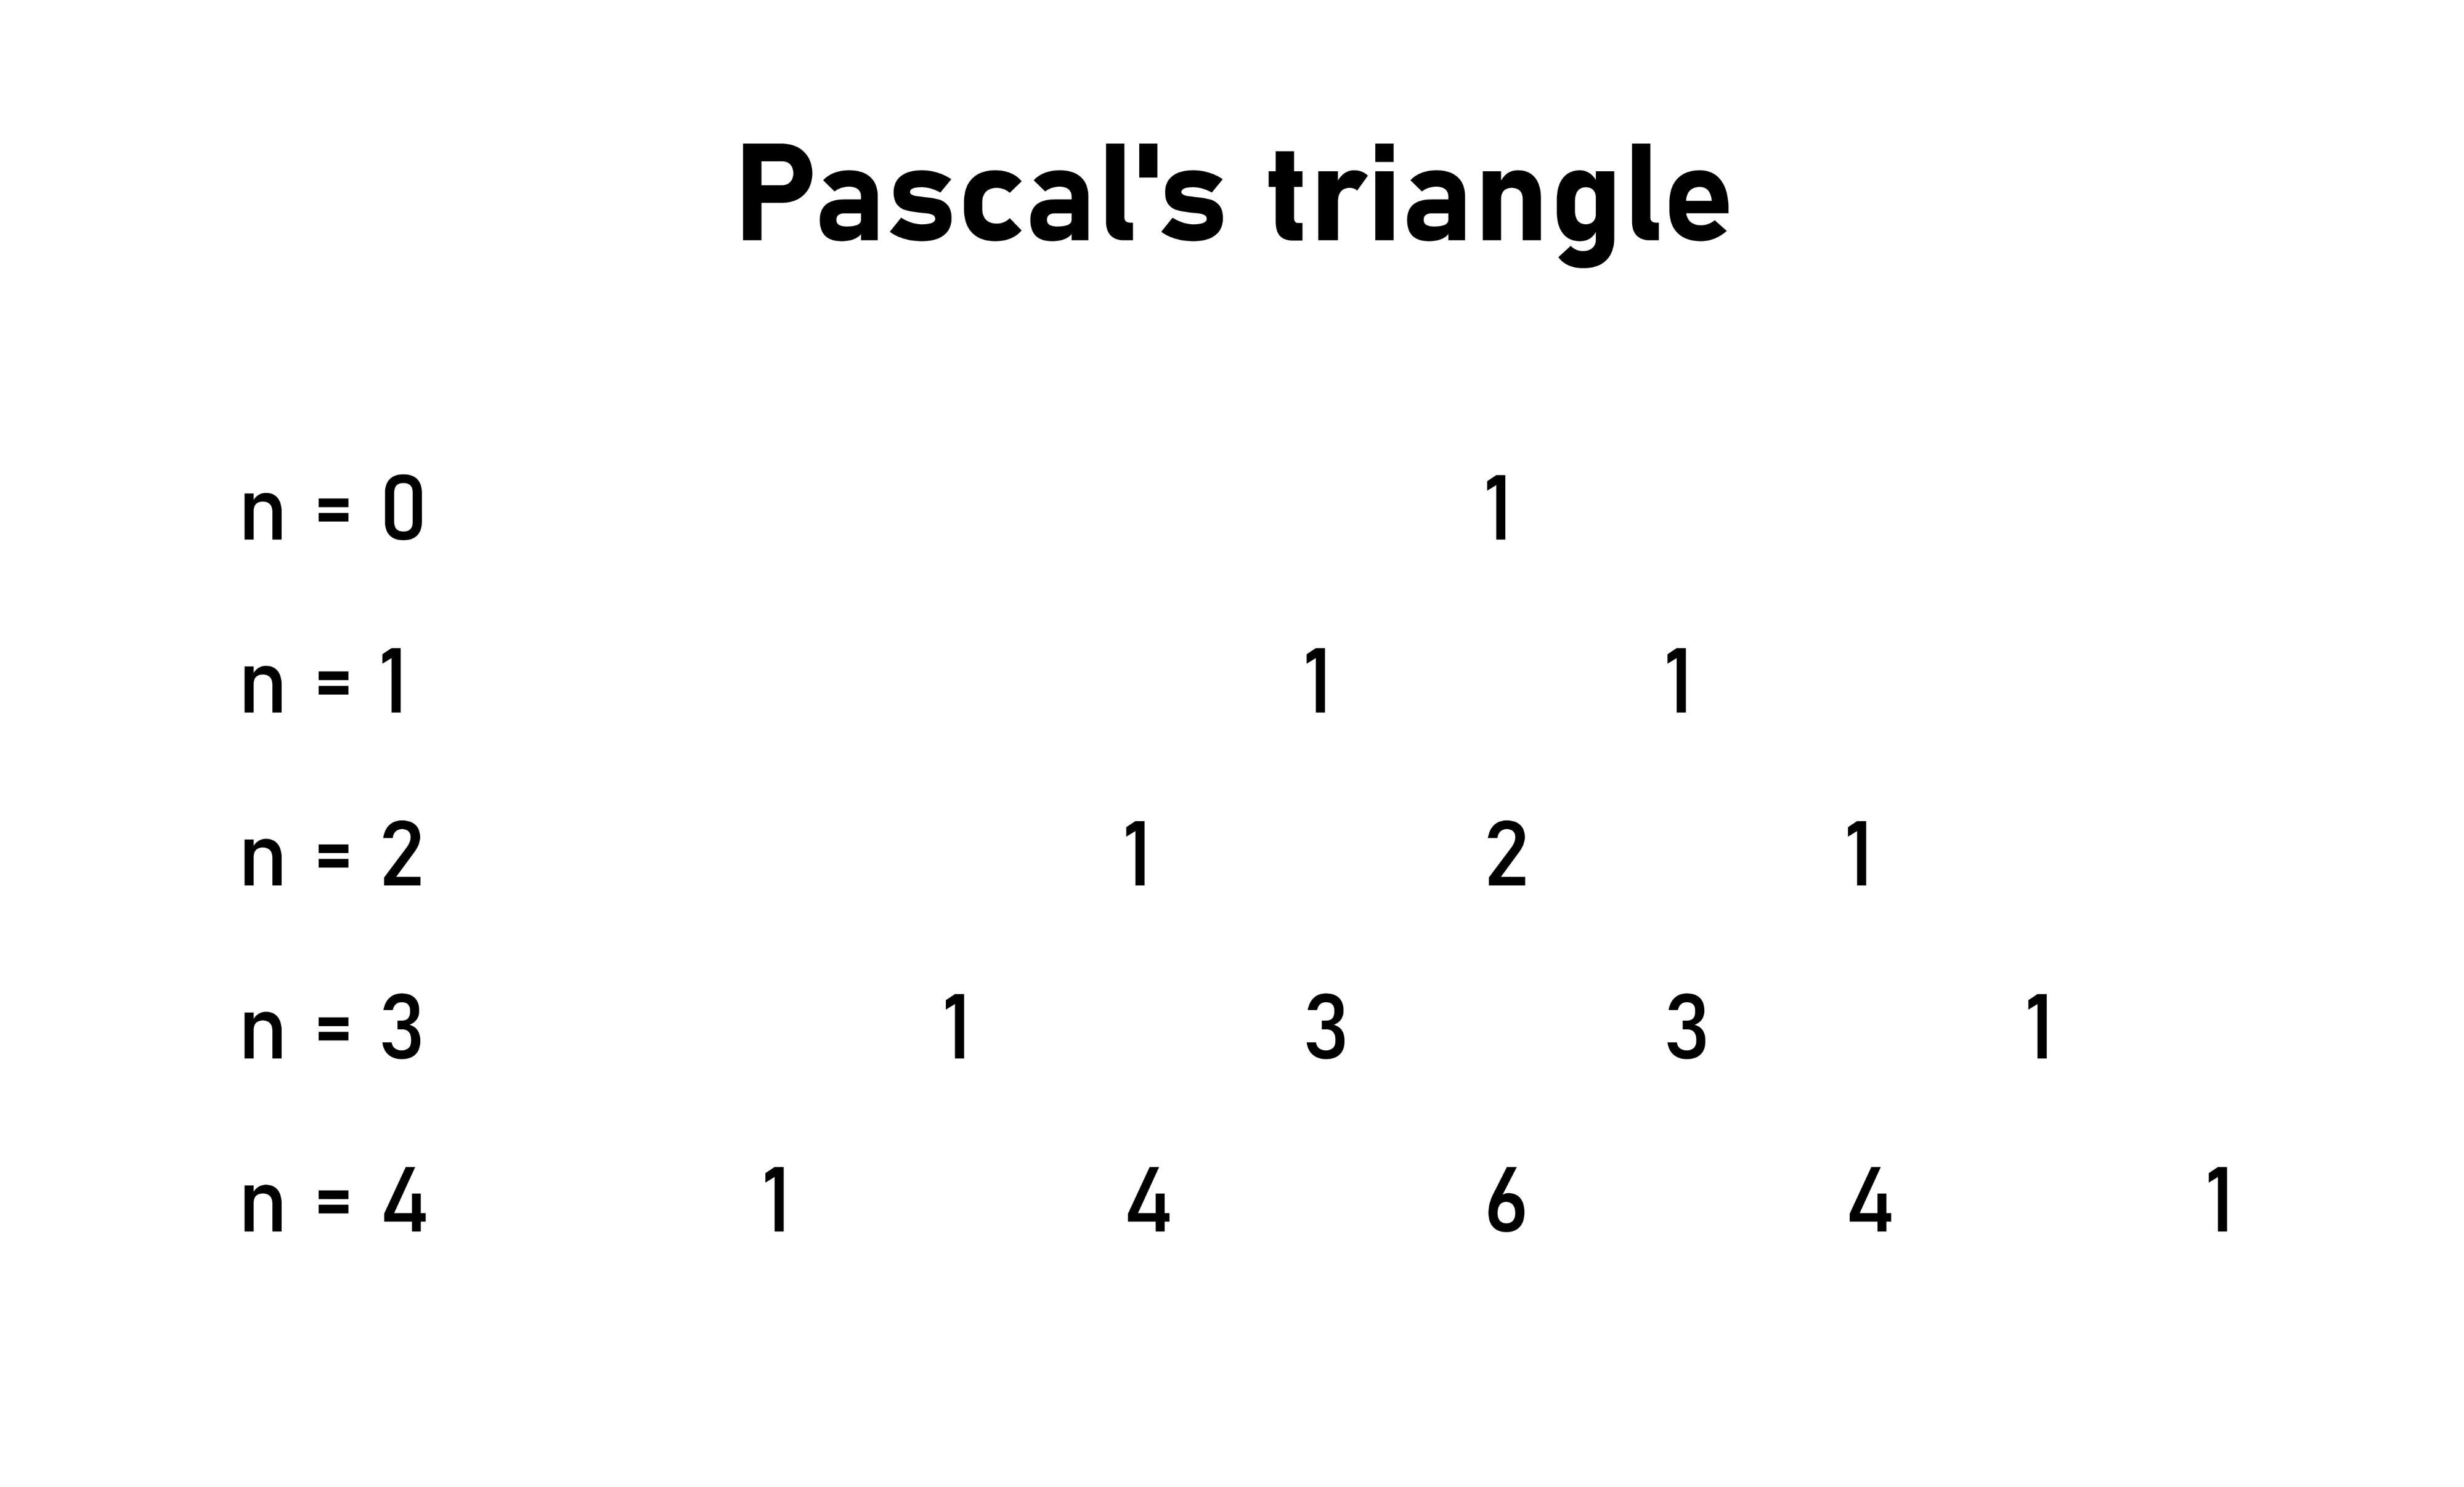


---

### 3. Why is this better? (Path-based vs. Recombining)

* **Path-based (Your current code):** You track every individual string path like `'uud'`, `'udu'`, `'duu'`.
  If $T=20$, you must process **1,048,576** paths! This is very slow and memory-heavy.
  
* **Recombining Lattice:** You only care about the "Number of Ups".
  If $T=20$, you only have **21** unique price nodes to calculate. This is nearly instantaneous.

---

### 4. Calculation

By using the **Binomial Coefficient** $C(T, j)$, we don't need to simulate paths one by one. We simply calculate the price for each **unique node** and multiply it by the **number of ways** to get there.

When we use the **Risk-Neutral Probability ($p$)**, the price of a European option at $t=0$ is simply the **Expected Value** of its future payoffs, discounted back to the present.

Instead of tracking every path, we group paths by the number of "Up" moves ($j$).

#### 1. The Core Formula

The value of the option ($V_0$) is given by:

$$V_0 = e^{-rT} \sum_{j=0}^{n} \left[ \binom{n}{j} p^j (1-p)^{n-j} \times \text{Payoff}(V_{n,j}) \right]$$

---

#### 2. Variable Definitions

* **$n$**: Total time steps (maturity).
* **$j$**: Total number of upward movements ($0, 1, ..., n$).
* **$p$**: Risk-neutral probability of an Up move: $p = \frac{e^{r\Delta t} - d}{u - d}$.
* **$\binom{n}{j}$**: The "Path Counter" (Binomial Coefficient). It tells us how many paths lead to $j$ ups.
* **$p^j (1-p)^{n-j}$**: The probability of any single path that has $j$ ups and $(n-j)$ downs.
* **$\text{Payoff}(S_{n,j})$**: The option value at the final node (e.g., $\max(V_{n,j} - K, 0)$ for a Call).

---

#### 3. Step-by-Step Numerical Example
**Scenario**: $S_0=20, K=30, T=3, u=2, d=0.5, r=0 \implies p=1/3$.

| Up Moves ($j$) | Paths $\binom{3}{j}$ | Prob $p^j(1-p)^{3-j}$ | Price $S_{3,j}$ | Payoff ($V_{3,j}$) |
| :--- | :--- | :--- | :--- | :--- |
| **3 Ups** | $\binom{3}{3} = 1$ | $1/27$ | $160$ | **$130$** |
| **2 Ups** | $\binom{3}{2} = 3$ | $6/27$ | $40$ | **$10$** |
| **1 Up** | $\binom{3}{1} = 3$ | $12/27$ | $10$ | $0$ |
| **0 Ups** | $\binom{3}{0} = 1$ | $8/27$ | $2.5$ | $0$ |



**Final Calculation**:
$$V_0 = \left( 1 \times \frac{1}{27} \times 130 \right) + \left( 3 \times \frac{2}{27} \times 10 \right) + 0 + 0$$
$$V_0 = \frac{130 + 60}{27} = \frac{190}{27} \approx 7.037$$

---


In [231]:
# Multi-step Binomial Model: European Options (Risk Netural Probability Method)
# Implementation: Recombining Lattice (State-aggregation by counting 'up' moves)
# Time Complexity: O(T^2) | Space Complexity: O(T)

import numpy as np
import math

def price_european_option_risk_neutral(s0, t_maturity, u, d, k, r, option_type='call'):
  p = (np.exp(r) - d) / (u - d)
  V0 = 0

  for j in range(t_maturity+1):
    St = s0 * (u ** j) * (d ** (t_maturity - j))
    Vt = get_eu_payoff(St, k, option_type)
    C = math.comb(t_maturity, j)

    V0 += C * (p ** j) * ((1 - p) ** (t_maturity - j)) * Vt

  return V0 * np.exp(- r * t_maturity)


In [232]:
price_european_option_risk_neutral(s0=20, t_maturity=20, u=1.5, d=0.35, k=11, r=0.04)

np.float64(18.523095810186277)